In [ ]:
import os
import torch
import gc
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/LDMX_GNN/GAIN')

2.11.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 91.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 72.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive


In [ ]:
from time import time
import copy
import math

import torch
import torch_geometric
import GNNTrackingTools as GTT
import models

from torch import optim
from torch.optim.lr_scheduler import StepLR
import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.data import Data, DataLoader, InMemoryDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import sklearn
import inspect

# Load data and setup Graph dataset

In [ ]:
run = 1

In [ ]:
tracker_name = 'Tagger'  # Either 'Tagger' or 'Recoil'

# Read data files
in_dir = '/content/drive/MyDrive/LDMX_GNN/data/inclusive_processed/'
df = GTT.load_pickle_files_to_dataframe(in_dir)

# Currently the ldmx-sw digitization processor outputs full 3D info
# Strip ambiguities must be added manually for consistency with CKF
df = GTT.add_strip_ambiguities(df, tracker_name)

In [ ]:
# Compute Info needed to build graphs
# GetGraphInfo requires two arguments: The number of primaries simulated and the tracker name (either 'Tagger' or 'Recoil')
df_graph = pd.DataFrame()
df_graph[['edge_index_0', 'edge_index_1', 'edge_feat_0', 'edge_feat_1', 'edge_feat_2','edge_label']]= df.apply(GTT.GetGraphInfo, axis=1, args=(tracker_name,), result_type='expand')
df_graph['SimParticles_n_primaries'] = df['SimParticles_n_primaries']
df_graph['Digi_x'] = df[f'{tracker_name}_Digi_x']
df_graph['Digi_y'] = df[f'{tracker_name}_Digi_y']
df_graph['Digi_z'] = df[f'{tracker_name}_Digi_z']
df_graph['Digi_trackID'] = df[f'{tracker_name}_Digi_trackID']
df_graph['Digi_Edep'] = df[f'{tracker_name}_Digi_Edep']
df_graph['TruthTrack_ID'] = df[f'{tracker_name}_TruthID']
df_graph['TruthTrack_P'] = df[f'{tracker_name}_TruthP']
df_graph['Digi_P'] = df_graph.apply(GTT.map_digi_to_momentum, axis=1)

# Free up some RAM
del df
gc.collect()


/content/drive/MyDrive/LDMX_GNN/GAIN/GNNTrackingTools.py:160: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.Tensor([self.df.Digi_x[idx], self.df.Digi_y[idx], self.df.Digi_z[idx]]).T


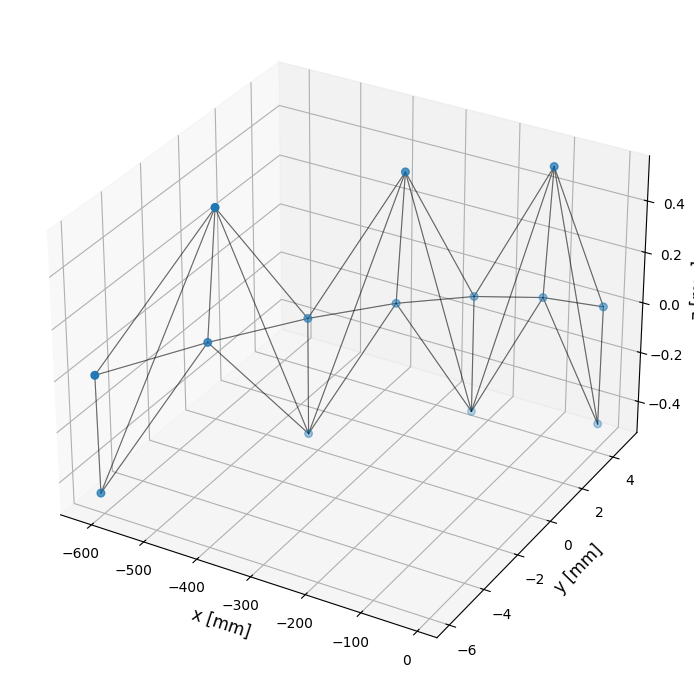

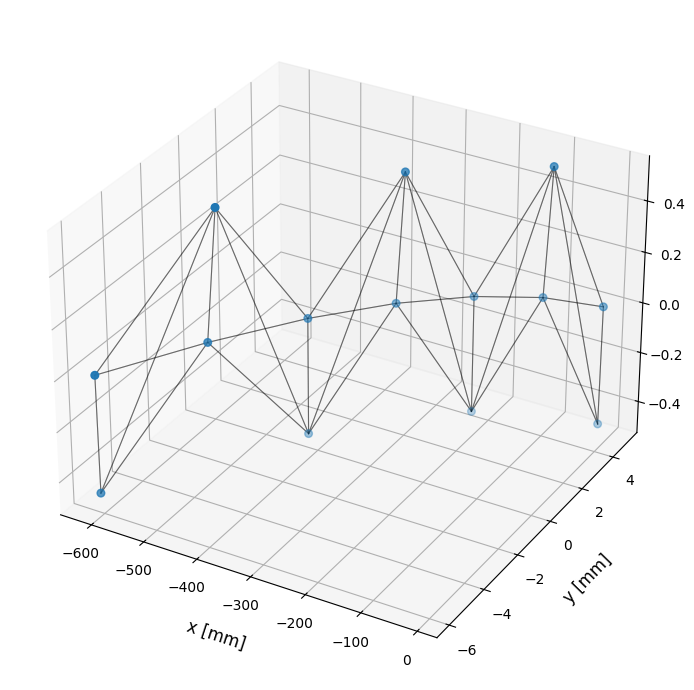

In [ ]:
# Make GNN dataset
dataset = GTT.MyInMemoryDataset(df_graph, tracker = tracker_name)

# Plot example graph
data = dataset[1]
GTT.plot_pyg_graph_3d(data, plot_truth=True)

In [ ]:
# Split into training, validation, and test sets
train_dataset, val_dataset, test_dataset = random_split(dataset, [0.7, 0.15, 0.15], generator=torch.Generator().manual_seed(42))

# Make DataLoaders
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


/tmp/ipykernel_5800/4059192093.py:6: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
/tmp/ipykernel_5800/4059192093.py:7: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
/tmp/ipykernel_5800/4059192093.py:8: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Initialize Model and Optimizer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Initialize model
hidden_size = 50

model = models.MyGAIN(hidden_size=hidden_size, heads = 8, base_dim=8).to(device)

total_trainable_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_trainable_params}")

Total trainable parameters: 384761


In [ ]:
# Initialize optimizer

lr = 5E-3
step_size = 5
gamma = 0.9

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

# Train the model

In [ ]:
epochs = 200

best_val_loss = math.inf
best_thld = None
best_state_dict = None  # or best_model = None

output = {'train_loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    print(f"---- Epoch {epoch} ----")
    train_loss = GTT.train(model, device, train_loader, optimizer, epoch)
    val_loss = GTT.validate(model, device, val_loader)

    # keep best model (lowest val loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())

    scheduler.step()

    output['train_loss'].append(train_loss)
    output['val_loss'].append(val_loss)


---- Epoch 1 ----
...epoch time: 38.57009696960449s
...epoch 1: train loss=0.46058445315337876
...val loss= 0.3222444992173802
---- Epoch 2 ----
...epoch time: 37.69769358634949s
...epoch 2: train loss=0.3094977298118536
...val loss= 0.2790344723246314
---- Epoch 3 ----
...epoch time: 38.2566180229187s
...epoch 3: train loss=0.27973603609117487
...val loss= 0.2821349081667987
---- Epoch 4 ----
...epoch time: 37.51294541358948s
...epoch 4: train loss=0.2540002642470656
...val loss= 0.21700936488129877
---- Epoch 5 ----
...epoch time: 37.50854730606079s
...epoch 5: train loss=0.2139816777509393
...val loss= 0.181935539977117
---- Epoch 6 ----
...epoch time: 38.279423236846924s
...epoch 6: train loss=0.18675792448728987
...val loss= 0.15536176684227856
---- Epoch 7 ----
...epoch time: 38.357035636901855s
...epoch 7: train loss=0.15306012614548786
...val loss= 0.13088797913356262
---- Epoch 8 ----
...epoch time: 38.280534505844116s
...epoch 8: train loss=0.13552256872497717
...val loss= 0.

KeyboardInterrupt: 

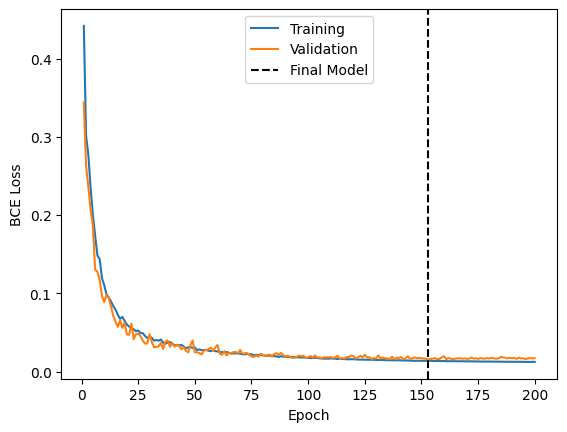

In [ ]:
# convert output to pandas DataFrame
output_df = pd.DataFrame(output)

# Plot the training and validation losses
plt.figure()
plt.plot(np.arange(len(output_df))+1,output_df.train_loss,label='Training')
plt.plot(np.arange(len(output_df))+1,output_df.val_loss,label='Validation')
plt.axvline(x=np.argmin(output_df['val_loss'])+1, linestyle='--', color='k', label='Final Model')

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
#plt.yscale('log')
plt.legend()




In [ ]:
# Save the best model state dictionary
torch.save(best_state_dict, '/content/drive/MyDrive/LDMX_GNN/data/state_dicts/GAIN_amb_large_'+tracker_name+'_state_dict_'+str(run)+'.pt')


# Test the final model

In [ ]:
model.load_state_dict(torch.load('/content/drive/MyDrive/LDMX_GNN/data/state_dicts/GAIN_amb_large_'+tracker_name+'_state_dict_'+str(run)+'.pt'))

test_loss, test_acc, test_TPR, test_TNR, labels, preds = GTT.test(model, device, test_loader)

print("test loss = ", test_loss)
print("test acc = ", test_acc)
print("test TPR = ", test_TPR)
print("test TNR = ", test_TNR)


test loss =  0.015500211453234608
test acc =  0.9925610465584587
test TPR =  0.9840478268984811
test TNR =  0.9955725602327173


Test AUROC: 0.99980452


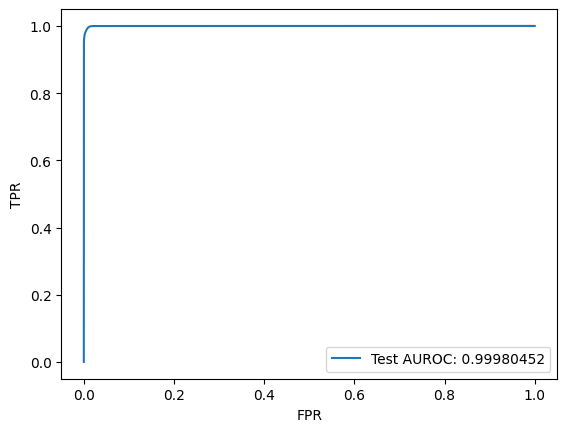

In [ ]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(labels, preds, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.8f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.8f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

In [ ]:
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Num_primaries = []
GNN_Tracks = []
Matched_tracks = []


# Minimum hits to construct a track, this should match whats used in TruthSeedProcessor (7 for Recoil tracker, 11 for Tagger tracker)
min_nodes = 6
# Threshold used for absolute edge labeling
thres = 0.9
# Fraction of hits in a GNN track belonging to a single truth track needed to match the,
match_frac = 0.5


# Check how many parameters the model's forward method takes
# If it's 4, the model take Edep as input feature
Nparams = len(inspect.signature(model.forward).parameters)

model.eval()
with torch.no_grad():
    for batch_idx, data in enumerate(test_loader):

        # Move datat to device
        data = data.to(device)

        # GNN inference - depends on whether Edep is used
        if Nparams == 4:
            output = model(data.x, data.Edep, data.edge_index, data.edge_attr)
        else:
            output = model(data.x, data.edge_index, data.edge_attr)

        data = data.cpu()
        output = output.cpu()

        # Use GNN prediction to create track candidates via connected_components
        y_pred = output.squeeze()>thres
        data.edge_index = data.edge_index[:,y_pred]
        tracks = data.connected_components()

        # Keep only tracks passing min_nodes requirement
        rm_idx = []
        for index, track in enumerate(tracks):
            if track.x.shape[0] <  min_nodes:
                rm_idx += [index]
        for i in sorted(rm_idx, reverse=True):
            del tracks[i]

        n_primaries = data.n_primaries.item()

        Num_primaries += [n_primaries]
        GNN_Tracks += [len(tracks)]

        # Get truth tracks
        truth_tracks = []
        # The Correspoonding Track ID for each Truth Track
        Truth_Track_IDs = []
        # The Truth Momentum for each Truth Track
        Truth_tracks_TruthPs = []
        for track_ID in np.arange(n_primaries)+1:
            # Create a filter for each batch ID and primary track ID, isolating truth tracks
            # Since track_ID only loops over the IDs of the primary tracks, it omits secondary tracks
            track_filter = (data.truthID==track_ID)
            n_hits = data.x[track_filter].shape[0]

            if n_hits >= min_nodes:
                truth_tracks += [data.x[track_filter]]
                Truth_Track_IDs += [track_ID]
                Truth_tracks_TruthPs += [torch.mean(data.truthP[track_filter]).item()] # All entries should be the same after the filter is applied


        matched_tracks = 0

        # Nested loop used to match Truth and GNN Tracks
        for truth_track in truth_tracks:

            for index, track in enumerate(tracks):

                # Find fraction of the GNN track that is contained in the truth track
                matches = (track.x[:, None, :] == truth_track[None, :, :]).all(dim=2).any(dim=1)
                count = matches.sum().item()

                # Tracks are matched based on the fraction of shared hits
                # This could be calculated as [matched hits] / [hits in GNN track] or [matched hits] / [hits in truth track]
                # By taking the minimum, I use whichever requirement is more strict
                frac_contained1 = count/truth_track.shape[0]
                frac_contained2 = count/track.x.shape[0]
                frac_contained = np.minimum(frac_contained1,frac_contained2)


                # If we find a matching GNN track, record relevant data, remove GNN track from list, and break
                # A track is matched if over 75% of the GNN track as contained in the truth track
                if frac_contained >= match_frac:
                    # Find fraction of hits not present in truth track
                    matched_tracks += 1
                    # collect truth P
                    del tracks[index]
                    break

        Matched_tracks += [matched_tracks]




# Create the DataFrame
df_results = pd.DataFrame({
    'Num_primaries': Num_primaries,
    'GNN_Tracks': GNN_Tracks,
    'Matched_tracks': Matched_tracks
})

/tmp/ipykernel_5800/3860779645.py:1: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


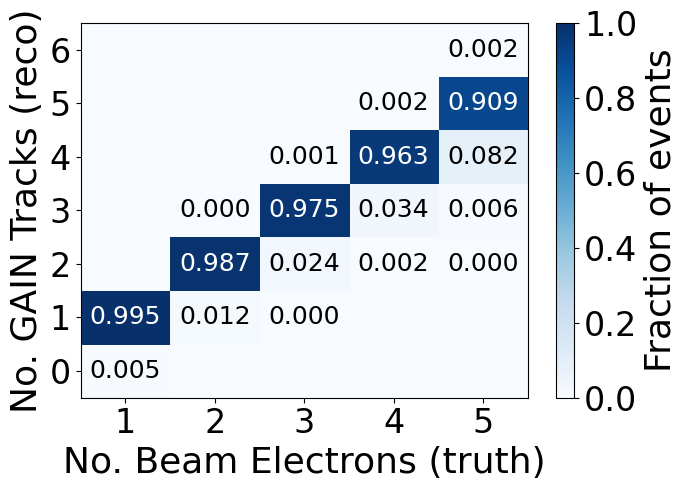

In [ ]:
# Confusion matrix: true track multiplicity vs reconstructed track multiplicity
true_vals = df_results['Num_primaries']
reco_vals = df_results['GNN_Tracks']

true_range = range(true_vals.min(), true_vals.max() + 1)
reco_range = range(reco_vals.min(), reco_vals.max() + 1)

# Build matrix: rows = GNN_Tracks (reco), cols = Num_primaries (truth)
matrix = np.zeros((len(reco_range), len(true_range)))
for i, r in enumerate(reco_range):
    for j, t in enumerate(true_range):
        matrix[i, j] = ((reco_vals == r) & (true_vals == t)).sum()

# Column-normalize so each truth column sums to 1
col_sums = matrix.sum(axis=0, keepdims=True)
matrix_norm = matrix / col_sums

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matrix_norm, origin='lower', aspect='auto', vmin=0, vmax=1, cmap='Blues')

ax.set_xticks(range(len(true_range)))
ax.set_xticklabels(list(true_range))
ax.set_yticks(range(len(reco_range)))
ax.set_yticklabels(list(reco_range))
ax.tick_params(labelsize=24)

ax.set_xlabel('No. Beam Electrons (truth)', fontsize=26)
ax.set_ylabel('No. GAIN Tracks (reco)', fontsize=26)

# Annotate cells
for i in range(len(reco_range)):
    for j in range(len(true_range)):
        val = matrix_norm[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=18, color='black' if val < 0.6 else 'white')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Fraction of events', fontsize=26)
cbar.ax.tick_params(labelsize=24)
plt.tight_layout()
plt.show()

In [ ]:

fake_rates= []

for my_index in np.arange(5)+1:
    df_cut = df_results.loc[df_results.Num_primaries == my_index]

    fake_rates += [np.sum(df_cut.GNN_Tracks-df_cut.Matched_tracks) / len(df_cut.Num_primaries)]

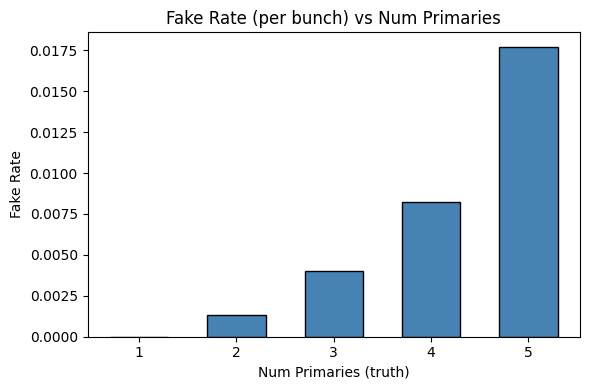

In [ ]:

n_primaries_vals = np.arange(5) + 1

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(n_primaries_vals, fake_rates, color='steelblue', edgecolor='black', width=0.6)

ax.set_xlabel('Num Primaries (truth)')
ax.set_ylabel('Fake Rate')
ax.set_title('Fake Rate (per bunch) vs Num Primaries')
ax.set_xticks(n_primaries_vals)
plt.tight_layout()
plt.show()
